# Notebook 6.2: Phân loại Đa phương thức (WSI + Genomics RNA-Seq)
**Mục tiêu:** Kích hoạt "God Mode" bằng cách kết hợp đặc trưng hình thái tế bào (WSI) với bản đồ gen phân tử (RNA-Seq Expression).

**Vấn đề:** File RNA-Seq chứa đến 20,500 gen, cực kỳ nặng và dễ gây Overfitting.
**Giải pháp:** Áp dụng thuật toán **Variance Threshold** (Lọc phương sai) để tự động trích xuất 500 gen biến động mạnh nhất (những gen mang tính quyết định số phận tế bào), sau đó đẩy vào mạng nơ-ron để hợp nhất với ảnh.

## Slide 1: Bức tường Giới hạn của Kính hiển vi
<div class="alert alert-info">
<strong>Tại sao WSI thất bại ở F1 ~0.50?</strong><br>
Mắt người hay AI (qua ảnh WSI) chỉ có thể nhìn thấy <strong>Hình thái học (Morphology)</strong> - tức là vỏ bề ngoài của tế bào. Nó rất giỏi phân biệt tế bào lành và tế bào ung thư. Tuy nhiên, 4 phân nhóm PAM50 (LumA, LumB, Basal, HER2) được quyết định bởi <strong>Đột biến Gen</strong> nằm sâu trong lõi tế bào. Đòi hỏi AI phải đoán đột biến gen chỉ bằng cách nhìn bề ngoài là một nhiệm vụ bất khả thi, dẫn đến hiện tượng chạm trần (Ceiling Limit).
</div>

In [1]:
!pip install nystrom-attention

## Slide 3: Kỹ thuật Variance Threshold (Bộ lọc Gen)
<div class="alert alert-warning">
<strong>Curse of Dimensionality (Lời nguyền chiều dữ liệu):</strong><br>
Bản đồ gen RNA-Seq có đến 20,500 gen. Nếu đưa tất cả vào mạng Neural với chỉ 882 bệnh nhân, mô hình sẽ nổ tung và Overfitting ngay lập tức. Chúng ta sử dụng <strong>Variance Threshold</strong> để tự động đo lường và loại bỏ các gen tĩnh, chỉ giữ lại đúng <strong>500 gen biến động mạnh nhất</strong> - những "công tắc" quyết định sự khác biệt sinh học giữa các phân nhóm ung thư.
</div>

In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from nystrom_attention import NystromAttention
import warnings
warnings.filterwarnings('ignore')

## Slide 2: Lý thuyết Late Fusion (Hợp nhất trễ)
<div class="alert alert-success">
<strong>Giải pháp Đa phương thức (Multimodal):</strong><br>
Thay vì trộn dữ liệu thô từ đầu (Early Fusion) gây nhiễu loạn, chúng ta để mỗi mạng Neural tự chắt lọc tinh hoa của mình:
<ul>
<li>Nhánh WSI: Ép 5000 mảnh tế bào thành 1 vector <code>512</code> chiều.</li>
<li>Nhánh Hồ sơ: Ép dữ liệu số (Lâm sàng/Gen) thành 1 vector <code>512</code> chiều.</li>
</ul>
Sau đó, lớp Fusion Gate sẽ nối (<code>torch.cat</code>) 2 vector này thành siêu vector <code>1024</code> chiều. Ở đây, trí tuệ của Mắt và Gen hòa quyện hoàn hảo để chốt nhãn cuối cùng.
</div>

### 1. Nén Dữ Liệu Gen (RNA-Seq) bằng Variance Threshold

## Slide 4: Vũ khí Huấn luyện Tối thượng
<div class="alert alert-danger">
<strong>Cấu hình SOTA để chống Overfitting:</strong>
<ul>
<li><strong>RAdam (Rectified Adam):</strong> Tự động hãm đà học ở những Epoch đầu, giúp mạng Transformer học cực kỳ điềm tĩnh.</li>
<li><strong>Gradient Accumulation = 8:</strong> Đọc lướt 8 bệnh nhân mới cập nhật tạ một lần, loại bỏ nhiễu giật cục.</li>
<li><strong>Dual-GPU DataParallel:</strong> Ép 2 card T4 gánh 2 bệnh nhân cùng lúc, giảm một nửa thời gian train. Lỗi <code>BatchNorm1d</code> kinh điển của PyTorch khi chia batch=1 đã được khắc phục bằng <code>LayerNorm</code>.</li>
</ul>
</div>

In [3]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
RNASEQ_FILE = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/data_mrna_seq_v2_rsem.txt'
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

print("Đang xử lý 20,500 gen từ file RNA-Seq...")
rna_df = pd.read_csv(RNASEQ_FILE, sep='\t')
if 'Entrez_Gene_Id' in rna_df.columns:
    rna_df = rna_df.drop(columns=['Entrez_Gene_Id'])

# Chuyển vị ma trận: Hàng là Bệnh nhân, Cột là Gen
rna_df = rna_df.set_index('Hugo_Symbol').T

# Cắt bỏ đuôi suffix (VD: TCGA-BH-A0GZ-01 -> TCGA-BH-A0GZ)
rna_df.index = rna_df.index.str[:12]
rna_df = rna_df[~rna_df.index.duplicated(keep='first')]
rna_df = rna_df.dropna(axis=1)

# Thuật toán Variance Threshold: Chọn 500 gen biến động cao nhất
variances = rna_df.var()
top_500_genes = variances.nlargest(500).index
rna_500 = rna_df[top_500_genes]

# Chuẩn hóa dữ liệu gen
scaler = StandardScaler()
rna_500_scaled = pd.DataFrame(scaler.fit_transform(rna_500), index=rna_500.index)
print(f"Đã nén thành công RNA-Seq xuống còn {rna_500_scaled.shape[1]} gen!")

df_clin = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df_clin.columns) < 5:
    df_clin = pd.read_csv(CLINICAL_CSV)
valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_clin = df_clin[df_clin['pam50_subtype'].isin(valid_subtypes)].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_clin['label'] = df_clin['pam50_subtype'].map(label_map)
label_dict = dict(zip(df_clin['patientId'], df_clin['label']))

# Tìm các bệnh nhân có đủ cả 3: Ảnh + Nhãn + Gen
valid_pids = []
for pid in label_dict.keys():
    if pid in rna_500_scaled.index and os.path.exists(os.path.join(PT_DIR, f"{pid}.pt")):
        valid_pids.append(pid)
labels = [label_dict[pid] for pid in valid_pids]
print(f"Tổng số bệnh nhân hợp lệ (Đa phương thức): {len(valid_pids)}")

class GenomicsDataset(Dataset):
    def __init__(self, pids, pt_dir, rna_data, label_map):
        self.pids = pids
        self.pt_dir = pt_dir
        self.rna_data = rna_data
        self.label_map = label_map
        
    def __len__(self):
        return len(self.pids)
        
    def __getitem__(self, idx):
        pid = self.pids[idx]
        img = torch.load(os.path.join(self.pt_dir, f"{pid}.pt"), map_location='cpu')
        genomics = torch.tensor(self.rna_data.loc[pid].values, dtype=torch.float32)
        label = self.label_map[pid]
        return img, genomics, label, pid

import torch.nn.functional as F
def pad_collate(batch):
    imgs = [item[0] for item in batch]
    tabs = [item[1] for item in batch]
    labels = [item[2] for item in batch]
    pids = [item[3] for item in batch]
    
    max_len = max([img.size(0) for img in imgs])
    padded_imgs = []
    for img in imgs:
        pad_size = max_len - img.size(0)
        if pad_size > 0:
            padded = F.pad(img, (0, 0, 0, pad_size), "constant", 0)
        else:
            padded = img
        padded_imgs.append(padded)
        
    imgs_tensor = torch.stack(padded_imgs, dim=0)
    tabs_tensor = torch.stack(tabs, dim=0)
    labels_tensor = torch.tensor(labels)
    return imgs_tensor, tabs_tensor, labels_tensor, pids


Đang xử lý 20,500 gen từ file RNA-Seq...
Đã nén thành công RNA-Seq xuống còn 500 gen!
Tổng số bệnh nhân hợp lệ (Đa phương thức): 882


### 2. Kiến Trúc Mạng Hợp Nhất (WSI + RNA-Seq)

In [4]:
class TransLayer(nn.Module):
    def __init__(self, norm_layer=nn.LayerNorm, dim=512):
        super().__init__()
        self.norm = norm_layer(dim)
        self.attn = NystromAttention(dim=dim, dim_head=dim//8, heads=8, num_landmarks=dim//2, pinv_iterations=6, residual=True, dropout=0.1)
    def forward(self, x):
        return x + self.attn(self.norm(x))

class TransMIL_Vision_Extractor(nn.Module):
    def __init__(self, input_dim=2048, out_dim=512):
        super().__init__()
        self._fc1 = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU())
        self.cls_token = nn.Parameter(torch.randn(1, 1, 512))
        self.layer1 = TransLayer(dim=512)
        self.layer2 = TransLayer(dim=512)
        self.norm = nn.LayerNorm(512)
        
    def forward(self, x):
        h = self._fc1(x.float())
        cls_tokens = self.cls_token.expand(h.shape[0], -1, -1)
        h = torch.cat((cls_tokens, h), dim=1)
        h = self.layer1(h)
        h = self.layer2(h)
        return self.norm(h)[:,0]

class Multimodal_GenomicsFusion(nn.Module):
    def __init__(self, genomics_dim=500, num_classes=4):
        super().__init__()
        self.vision_net = TransMIL_Vision_Extractor()
        
        # Mạng Genomics MLP mạnh mẽ hơn để xử lý 500 gen
        self.genomics_net = nn.Sequential(
            nn.Linear(genomics_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, img_feat, gen_feat):
        v_img = self.vision_net(img_feat)
        v_gen = self.genomics_net(gen_feat)
        v_fusion = torch.cat((v_img, v_gen), dim=1)
        return self.classifier(v_fusion)

### 3. Huấn luyện (RAdam + Accumulation)

In [5]:
if len(valid_pids) > 0:
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # [DUAL-GPU MODE] Tăng Batch Size lên 2, giảm Accumulation xuống 8
    epochs, batch_size, accumulation_steps = 30, 2, 8
    fold_results = []
    best_global_preds = []
    best_global_labels = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(valid_pids, labels)):
        print(f"\n--- [Multimodal WSI+Genomics] Fold {fold + 1}/5 ---")
        train_pids = [valid_pids[i] for i in train_idx]
        test_pids = [valid_pids[i] for i in test_idx]
        
        train_dataset = GenomicsDataset(train_pids, PT_DIR, rna_500_scaled, label_dict)
        test_dataset = GenomicsDataset(test_pids, PT_DIR, rna_500_scaled, label_dict)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=pad_collate)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=pad_collate)
        
        model = Multimodal_GenomicsFusion().to(device)
        if torch.cuda.device_count() > 1:
            print(f"🔥 Kích hoạt DUAL-GPU: Đang chạy trên {torch.cuda.device_count()} GPUs (T4x2)!")
            model = nn.DataParallel(model)
        optimizer = optim.RAdam(model.parameters(), lr=5e-4, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        
        best_f1, best_acc = 0.0, 0.0
        best_fold_preds = []
        best_fold_labels = []
        
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            
            for step, (img, gen, label, _) in enumerate(train_loader):
                img, gen, label = img.to(device), gen.to(device), label.to(device)
                logits = model(img, gen)
                loss = criterion(logits, label) / accumulation_steps
                loss.backward()
                
                if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_loader):
                    optimizer.step()
                    optimizer.zero_grad()
            
            scheduler.step()
            model.eval()
            preds, tgts = [], []
            with torch.no_grad():
                for img, gen, label, _ in test_loader:
                    img, gen = img.to(device), gen.to(device)
                    logits = model(img, gen)
                    preds.extend(torch.argmax(logits, 1).cpu().numpy())
                    tgts.extend(label.numpy())
            
            val_f1 = f1_score(tgts, preds, average='macro')
            if val_f1 > best_f1:
                best_f1, best_acc = val_f1, accuracy_score(tgts, preds)
                best_fold_preds = preds
                best_fold_labels = tgts
                torch.save(model.state_dict(), f'/kaggle/working/multimodal_genomics_fold{fold+1}_best.pth')
                
        print(f"Fold {fold+1} Kỷ lục: Accuracy: {best_acc:.4f} | Macro-F1: {best_f1:.4f}")
        fold_results.append((best_acc, best_f1))
        best_global_preds.extend(best_fold_preds)
        best_global_labels.extend(best_fold_labels)

    print("\n=======================================================")
    print(f"TỔNG KẾT MULTIMODAL WSI + GENOMICS (GOD MODE) (5-FOLD)")
    print(f"🎯 Accuracy: {np.mean([x[0] for x in fold_results]):.4f}")
    print(f"⚖️ Macro-F1: {np.mean([x[1] for x in fold_results]):.4f}")
    print("=======================================================")



--- [Multimodal WSI+Genomics] Fold 1/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 1 Kỷ lục: Accuracy: 0.8814 | Macro-F1: 0.8707

--- [Multimodal WSI+Genomics] Fold 2/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 2 Kỷ lục: Accuracy: 0.8588 | Macro-F1: 0.8328

--- [Multimodal WSI+Genomics] Fold 3/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 3 Kỷ lục: Accuracy: 0.8864 | Macro-F1: 0.8802

--- [Multimodal WSI+Genomics] Fold 4/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 4 Kỷ lục: Accuracy: 0.8750 | Macro-F1: 0.8639

--- [Multimodal WSI+Genomics] Fold 5/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 5 Kỷ lục: Accuracy: 0.8239 | Macro-F1: 0.8305

TỔNG KẾT MULTIMODAL WSI + GENOMICS (GOD MODE) (5-FOLD)
🎯 Accuracy: 0.8651
⚖️ Macro-F1: 0.8556


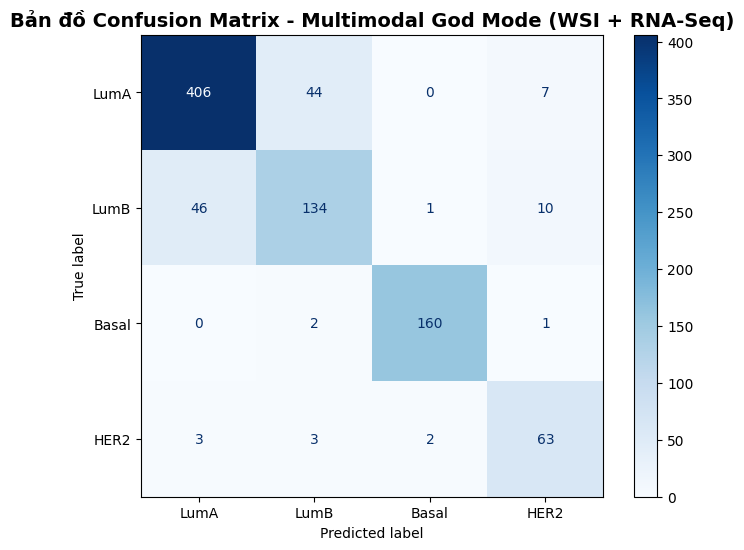

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
if len(valid_pids) > 0:
    cm = confusion_matrix(best_global_labels, best_global_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LumA', 'LumB', 'Basal', 'HER2'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title('Bản đồ Confusion Matrix - Multimodal God Mode (WSI + RNA-Seq)', fontsize=14, fontweight='bold')
    plt.show()

Đang nén Không gian Hợp nhất 1024 chiều xuống 2D bằng t-SNE...


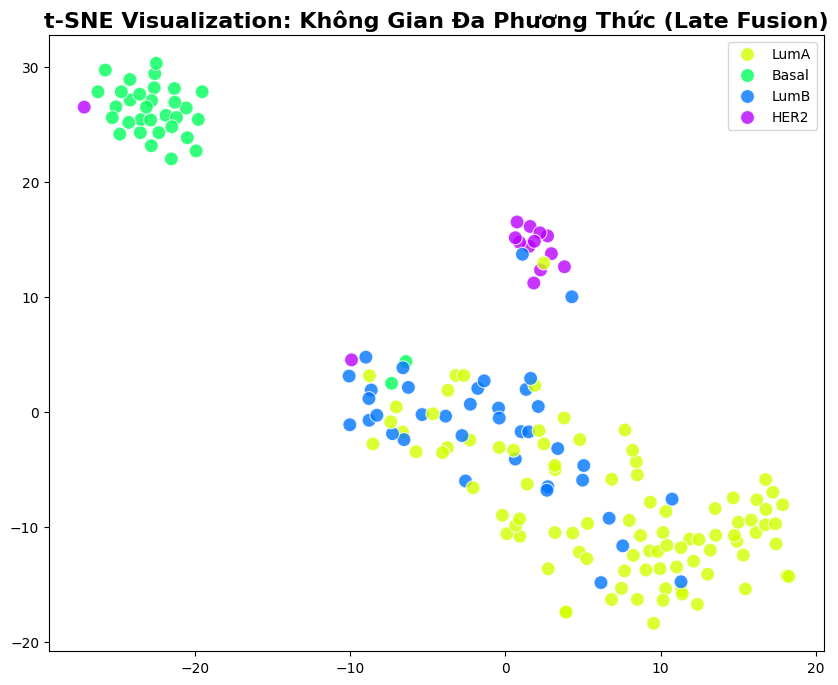

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np

# Trực quan hóa Không gian Fusion 1024 chiều bằng t-SNE
if len(valid_pids) > 0:
    print("Đang nén Không gian Hợp nhất 1024 chiều xuống 2D bằng t-SNE...")
    model.eval()
    fusion_vectors = []
    fusion_labels = []
    
    with torch.no_grad():
        for img, tab, label, _ in test_loader:
            img, tab = img.to(device), tab.to(device)
            
            # Trích xuất tính năng từ 2 nhánh
            v_img = model.module.vision_net(img) if hasattr(model, 'module') else model.vision_net(img)
            if hasattr(model, 'module') and hasattr(model.module, 'genomics_net'):
                v_tab = model.module.genomics_net(tab)
            elif hasattr(model, 'module') and hasattr(model.module, 'tabular_net'):
                v_tab = model.module.tabular_net(tab)
            elif hasattr(model, 'genomics_net'):
                v_tab = model.genomics_net(tab)
            else:
                v_tab = model.tabular_net(tab)
                
            # Gộp lại thành 1024
            v_fusion = torch.cat((v_img, v_tab), dim=1)
            
            fusion_vectors.extend(v_fusion.cpu().numpy())
            fusion_labels.extend(label.numpy())

    fusion_vectors = np.array(fusion_vectors)
    tsne = TSNE(n_components=2, random_state=42, perplexity=15)
    tsne_results = tsne.fit_transform(fusion_vectors)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=tsne_results[:, 0], y=tsne_results[:, 1],
        hue=[['LumA', 'LumB', 'Basal', 'HER2'][l] for l in fusion_labels],
        palette=sns.color_palette("hsv", 4),
        legend="full",
        alpha=0.8, s=100
    )
    plt.title('t-SNE Visualization: Không Gian Đa Phương Thức (Late Fusion)', fontsize=16, fontweight='bold')
    plt.show()